# Ising model: start with a spin configuration

**PHY4008 · Computational Physics II**

Create one spin array, change it, measure it, and build one Monte Carlo step.
Run the cells in order with a Python kernel containing NumPy and Matplotlib.

## 1. Create a spin configuration

Each entry is one spin: $+1$ or $-1$. The whole array is one **configuration**.
Start with a small array that we can read by hand.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

spins = np.array([
    [1, 1, -1, -1],
    [1, 1, -1, -1],
    [1, 1, -1, -1],
    [1, 1, -1, -1],
])
spins

array([[ 1,  1, -1, -1],
       [ 1,  1, -1, -1],
       [ 1,  1, -1, -1],
       [ 1,  1, -1, -1]])

`spins[i, j]` selects row `i` and column `j`. Indices start at zero.
Predict each output before running the next cell.

In [2]:
print("Shape:", spins.shape)
print("Number of spins:", spins.size)
print("Row 0, column 2:", spins[0, 2])
print("First row:", spins[0, :])
print("First column:", spins[:, 0])

Shape: (4, 4)
Number of spins: 16
Row 0, column 2: -1
First row: [ 1  1 -1 -1]
First column: [1 1 1 1]


## 2. Visualize and change spins

Each square below is one array entry: white is $+1$, black is $-1$.
The first row appears at the top; fix the color limits so the colors always mean the same thing.
Grid lines mark cell boundaries; the numbered ticks mark spin positions.

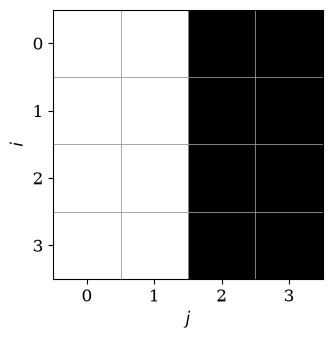

In [3]:
plt.rcParams.update({"font.family": "serif", "font.size": 12,
                     "xtick.direction": "out", "ytick.direction": "out"})
plt.figure(figsize=(3.5, 3.5))
plt.imshow(spins, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
plt.xticks(range(4))
plt.yticks(range(4))
plt.xticks(np.arange(-0.5, 4, 1), minor=True)
plt.yticks(np.arange(-0.5, 4, 1), minor=True)
plt.grid(which="minor", color="#999999", linewidth=0.6)
plt.tick_params(which="minor", length=0)
plt.xlabel(r"$j$")
plt.ylabel(r"$i$")
plt.show()

We will draw arrays repeatedly. Put the plotting lines we just used into a function.
`show_spins` draws on the current plot; `plt.show()` displays it.

In [4]:
def show_spins(spins):
    L = len(spins)
    plt.imshow(spins, cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
    plt.xticks(range(L))
    plt.yticks(range(L))
    plt.xticks(np.arange(-0.5, L, 1), minor=True)
    plt.yticks(np.arange(-0.5, L, 1), minor=True)
    plt.grid(which="minor", color="#999999", linewidth=0.6)
    plt.tick_params(which="minor", length=0)
    plt.xlabel(r"$j$")
    plt.ylabel(r"$i$")

Make a copy and flip one spin by multiplying it by $-1$.
`trial = spins` would give another name to the same array; `.copy()` keeps the original separate.

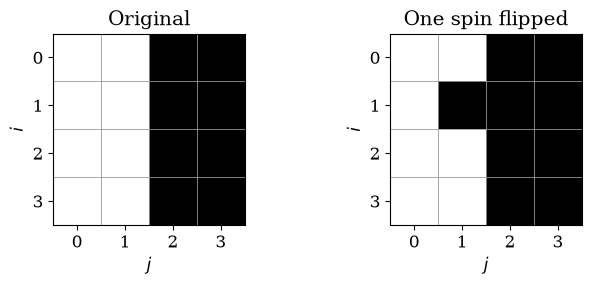

In [5]:
trial = spins.copy()
trial[1, 1] *= -1

plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
show_spins(spins)
plt.title("Original")
plt.subplot(1, 2, 2)
show_spins(trial)
plt.title("One spin flipped")
plt.tight_layout()
plt.show()

**Try:** flip a whole row or set a block of spins to the same value.
Change the indices below and predict which squares will change. Each example starts from a fresh copy.

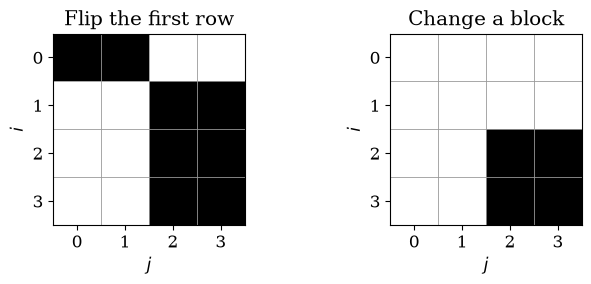

In [6]:
row_flip = spins.copy()
row_flip[0, :] *= -1
block_change = spins.copy()
block_change[0:2, 2:4] = 1

plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
show_spins(row_flip)
plt.title("Flip the first row")
plt.subplot(1, 2, 2)
show_spins(block_change)
plt.title("Change a block")
plt.tight_layout()
plt.show()

Make a few configurations with recognizable patterns. Keep them for later comparisons.
`np.ones_like(spins)` creates an array of ones with the same shape.

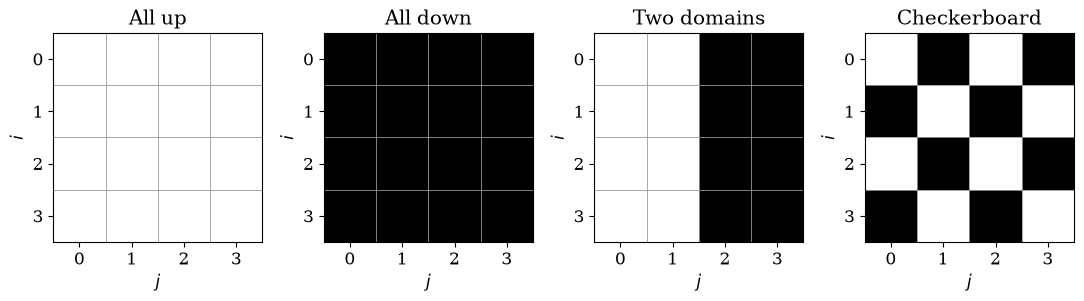

In [7]:
domains = spins.copy()
all_up = np.ones_like(spins)
all_down = -all_up
checkerboard = np.array([
    [1, -1, 1, -1],
    [-1, 1, -1, 1],
    [1, -1, 1, -1],
    [-1, 1, -1, 1],
])

patterns = [all_up, all_down, domains, checkerboard]
names = ["All up", "All down", "Two domains", "Checkerboard"]
plt.figure(figsize=(11, 3))
for k in range(4):
    plt.subplot(1, 4, k + 1)
    show_spins(patterns[k])
    plt.title(names[k])
plt.tight_layout()
plt.show()

## 3. Measure magnetization

The total magnetization $M$ is the sum of all spins. Divide by the number of spins $N$ to obtain the magnetization per spin $m$.

$$M=\sum_{i,j}s_{ij},\qquad m=\frac{M}{N}.$$

Count the positive and negative entries in `spins` before running the cell.

In [8]:
M = spins.sum()
m = M / spins.size
print("Total magnetization:", M)
print("Magnetization per spin:", m)

Total magnetization: 0
Magnetization per spin: 0.0


Name the calculation and reuse it. Our function returns **total** magnetization $M$.
Which configurations have the same magnetization despite looking different?

In [9]:
def magnetization(spins):
    return spins.sum()

for k in range(4):
    M = magnetization(patterns[k])
    print(names[k], "M =", M, "m =", M / patterns[k].size)

All up M = 16 m = 1.0
All down M = -16 m = -1.0
Two domains M = 0 m = 0.0
Checkerboard M = 0 m = 0.0


## 4. Calculate the energy

Neighboring spins interact. For one bond, equal spins lower the energy and opposite spins raise it:

$$E_{ab}=-J s_a s_b.$$

Use ferromagnetic coupling $J=1$ and no external field throughout this notebook.
Energy is measured in units of $J$. First calculate just one bond.

In [10]:
s1 = 1
s2 = -1
bond_energy = -s1 * s2
print("Bond energy:", bond_energy)

Bond energy: 1


### Periodic neighbors

The last column connects to the first column, and the last row connects to the first row.
The remainder operator `%` wraps an index: for our lattice, $(3+1)\bmod4=0$.
Try a corner below and identify its right and down neighbors in the array.

In [11]:
L = len(spins)
i, j = 3, 3
right_j = (j + 1) % L
down_i = (i + 1) % L
print("Selected:", (i, j), spins[i, j])
print("Right:", (i, right_j), spins[i, right_j])
print("Down:", (down_i, j), spins[down_i, j])

Selected: (3, 3) -1
Right: (3, 0) 1
Down: (0, 3) -1


### Add the bonds

Visit every site and add its right and down bonds. This counts each undirected bond once.
We use square arrays with $L\geq3$; each spin then has four distinct neighbors.

$$E=-\sum_{i=0}^{L-1}\sum_{j=0}^{L-1}s_{ij}
\left(s_{i,(j+1)\bmod L}+s_{(i+1)\bmod L,j}\right).$$

In [12]:
energy = 0
for i in range(L):
    for j in range(L):
        right = spins[i, (j + 1) % L]
        down = spins[(i + 1) % L, j]
        energy -= spins[i, j] * right
        energy -= spins[i, j] * down
print("Total energy:", energy)

Total energy: -16


Wrap the same calculation in a function. Compute the size from the argument so the function works on another square array.
Temperature is not needed to calculate the energy of a given configuration.

In [13]:
def total_energy(spins):
    L = len(spins)
    energy = 0
    for i in range(L):
        for j in range(L):
            right = spins[i, (j + 1) % L]
            down = spins[(i + 1) % L, j]
            energy -= spins[i, j] * right
            energy -= spins[i, j] * down
    return energy

### Check configurations we understand

A periodic $4\times4$ lattice has $32$ bonds. All-up has energy $-32$; checkerboard has energy $+32$.
Flipping one spin in all-up changes four bonds from $-1$ to $+1$, increasing the energy by $8$.

| Configuration | $E$ | $M$ |
| --- | ---: | ---: |
| All up | $-32$ | $16$ |
| All down | $-32$ | $-16$ |
| Two domains | $-16$ | $0$ |
| Checkerboard | $32$ | $0$ |
| One flipped spin in all-up | $-24$ | $14$ |

In [14]:
one_flip = all_up.copy()
one_flip[1, 1] *= -1

for k in range(4):
    state = patterns[k]
    print(names[k], "E =", total_energy(state), "M =", magnetization(state))
print("One flipped spin", "E =", total_energy(one_flip), "M =", magnetization(one_flip))

assert total_energy(all_up) == -32
assert total_energy(domains) == -16
assert total_energy(checkerboard) == 32
assert total_energy(one_flip) - total_energy(all_up) == 8

All up E = -32 M = 16
All down E = -32 M = -16
Two domains E = -16 M = 0
Checkerboard E = 32 M = 0
One flipped spin E = -24 M = 14


**Explain:** two domains and checkerboard both have $M=0$. Why are their energies different?

## 5. Flip one spin

Choose a site by hand, make a candidate array, and calculate both energies.
The energy change belongs to this particular proposed flip:

$$\Delta E=E(\mathrm{trial})-E(\mathrm{spins}).$$

In [15]:
spins = domains.copy()
i, j = 1, 1
trial = spins.copy()
trial[i, j] *= -1

E_before = total_energy(spins)
E_after = total_energy(trial)
delta_E = E_after - E_before
print("Before:", E_before, "After:", E_after, "Change:", delta_E)
print("Magnetization:", magnetization(spins), "to", magnetization(trial))

Before: -16 After: -12 Change: 4
Magnetization: 0 to -2


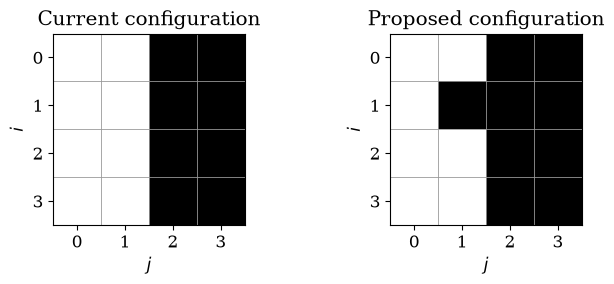

In [16]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
show_spins(spins)
plt.title("Current configuration")
plt.subplot(1, 2, 2)
show_spins(trial)
plt.title("Proposed configuration")
plt.tight_layout()
plt.show()

**Try:** replace `domains.copy()` above with `all_up.copy()`, then `one_flip.copy()`.
Keep the chosen site at `(1, 1)`. Predict the sign of the energy change each time.
The original array stays unchanged until we accept a proposal.

## 6. One Metropolis step

Accept a proposed flip if its energy decreases or stays equal. If the energy increases, accept it with a temperature-dependent probability:

$$P_{\mathrm{accept}}=\begin{cases}
1,&\Delta E\leq0,\\
\exp(-\Delta E/T),&\Delta E>0.
\end{cases}$$

Here `T` means $k_{\mathrm B}T/J$ and must be positive.
Allowing some energy-increasing moves represents thermal fluctuations.

First use a fixed energy increase, $\Delta E=4$, and a fixed test number $u=0.2$.
Accept when $u<P_{\mathrm{accept}}$. How does changing the temperature affect this decision?

In [17]:
delta_E = 4
u = 0.2
for T in [1.0, 2.0, 4.0]:
    p_accept = np.exp(-delta_E / T)
    print("T =", T, "probability =", round(p_accept, 3), "accepted:", u < p_accept)

T = 1.0 probability = 0.018 accepted: False
T = 2.0 probability = 0.135 accepted: False
T = 4.0 probability = 0.368 accepted: True


### Draw a random proposal

Now choose a random row, a random column, and a random $u$ in $[0,1)$.
Create the random generator once; subsequent calls continue its sequence.
The seed makes a run reproducible in the same software environment.

In [18]:
rng = np.random.default_rng(42)
T = 2.0
L = len(spins)
i = rng.integers(L)
j = rng.integers(L)
trial = spins.copy()
trial[i, j] *= -1
delta_E = total_energy(trial) - total_energy(spins)

p_accept = 1.0
if delta_E > 0:
    p_accept = np.exp(-delta_E / T)
u = rng.random()
accepted = u < p_accept
print("Row:", i, "Column:", j, "Energy change:", delta_E)
print("Probability:", round(p_accept, 3), "Random number:", round(u, 3))
print("Accepted:", accepted)

Row: 0 Column: 3 Energy change: 4
Probability: 0.135 Random number: 0.439
Accepted: False


Select the next configuration. A rejection keeps the current configuration; it still counts as one attempted step.

In [19]:
if accepted:
    next_spins = trial
else:
    next_spins = spins

print("Current configuration:")
print(spins)
print("Next configuration:")
print(next_spins)

Current configuration:
[[ 1  1 -1 -1]
 [ 1  1 -1 -1]
 [ 1  1 -1 -1]
 [ 1  1 -1 -1]]
Next configuration:
[[ 1  1 -1 -1]
 [ 1  1 -1 -1]
 [ 1  1 -1 -1]
 [ 1  1 -1 -1]]


### Put the step in a function

Reuse exactly the operations above. The function returns the next array and whether the move was accepted.
It never changes its input array. A uniformly chosen single-spin flip is a symmetric proposal; this acceptance rule gives the Boltzmann distribution as a stationary distribution.

In [20]:
def metropolis_step(spins, T, rng):
    if T <= 0:
        raise ValueError("T must be positive.")
    L = len(spins)
    i = rng.integers(L)
    j = rng.integers(L)
    trial = spins.copy()
    trial[i, j] *= -1
    delta_E = total_energy(trial) - total_energy(spins)

    p_accept = 1.0
    if delta_E > 0:
        p_accept = np.exp(-delta_E / T)
    accepted = rng.random() < p_accept
    if accepted:
        return trial, True
    return spins, False

Call the function once. Rerun this cell to make another attempt from the resulting configuration.

Accepted: False
Energy: -16
Magnetization: 0


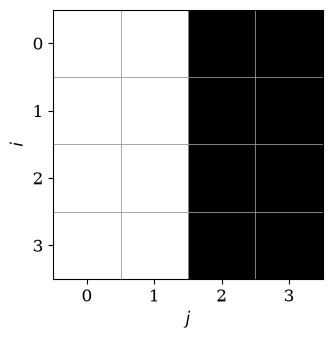

In [21]:
spins, accepted = metropolis_step(spins, T, rng)
print("Accepted:", accepted)
print("Energy:", total_energy(spins))
print("Magnetization:", magnetization(spins))
plt.figure(figsize=(3.5, 3.5))
show_spins(spins)
plt.show()

## 7. Repeat and inspect

Start a new experiment from the two-domain array and attempt $50$ flips.
Record the initial state and the state after **every attempt**, including rejections.
Only the loop is new; it calls the functions we already understand.

In [22]:
spins = domains.copy()
rng = np.random.default_rng(42)
T = 2.0
n_steps = 50
configurations = [spins.copy()]
energies = [total_energy(spins)]
magnetizations = [magnetization(spins)]
acceptances = []

for step in range(n_steps):
    spins, accepted = metropolis_step(spins, T, rng)
    configurations.append(spins.copy())
    energies.append(total_energy(spins))
    magnetizations.append(magnetization(spins))
    acceptances.append(accepted)

Compare the initial configuration with the configurations after $10$ and $50$ attempted flips.
Each attempt chooses a site again, so the same site can be selected more than once.

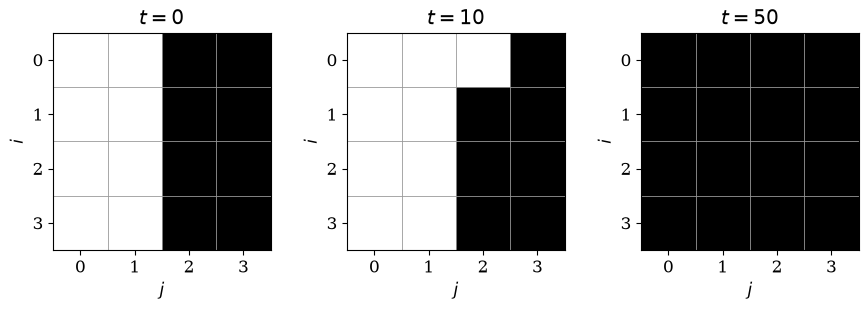

In [23]:
shown_steps = [0, 10, n_steps]
plt.figure(figsize=(9, 3))
for k in range(3):
    step = shown_steps[k]
    plt.subplot(1, 3, k + 1)
    show_spins(configurations[step])
    plt.title(rf"$t={step}$")
plt.tight_layout()
plt.show()

Plot total energy and total magnetization against the attempt number $t$.
Energy need not decrease at every step. An accepted flip can also leave energy unchanged; a rejection repeats both $E$ and $M$.

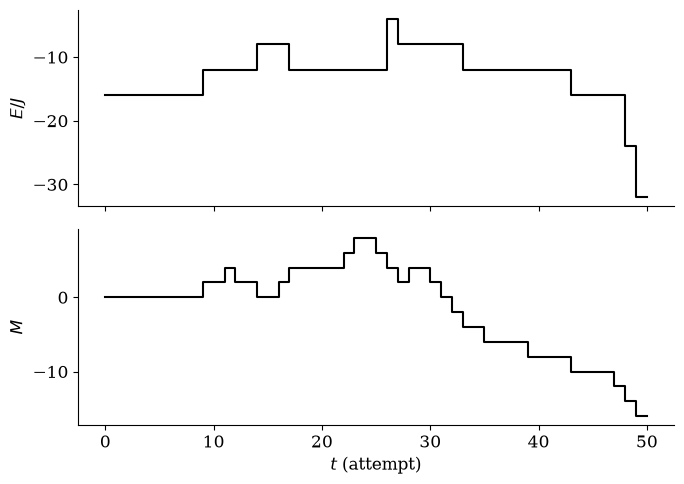

Accepted: 22 Rejected: 28


In [24]:
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].step(range(n_steps + 1), energies, where="post", color="black")
axes[0].set_ylabel(r"$E/J$")
axes[1].step(range(n_steps + 1), magnetizations, where="post", color="black")
axes[1].set_ylabel(r"$M$")
axes[1].set_xlabel(r"$t$ (attempt)")
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
print("Accepted:", sum(acceptances), "Rejected:", n_steps - sum(acceptances))

**Try:** change the temperature in the experiment cell, then rerun that cell and the two plots below it.
These short runs show how the algorithm works; they are not estimates of equilibrium averages or a transition temperature.

## 8. Below and above the critical temperature

For the infinite square-lattice Ising model at zero field, the critical temperature is

$$\frac{k_{\mathrm B}T_c}{J}=\frac{2}{\ln(1+\sqrt{2})}\approx2.269.$$

Compare $T=1.5<T_c$ and $T=3.5>T_c$ on a slightly larger lattice.
Both runs start from the **same random configuration** and use our existing `metropolis_step`.

In [25]:
rng = np.random.default_rng(42)
initial = rng.choice([-1, 1], size=(12, 12))
temperatures = [1.5, 3.5]
n_sweeps = 500

One **sweep** means $N$ attempted flips, where $N$ is the number of spins.
Sites are chosen again at each attempt; a sweep does not guarantee that every site is visited.
After each sweep, record the magnetization per spin $m=M/N$.

In [26]:
final_states = []
m_traces = []
for T in temperatures:
    spins = initial.copy()
    rng = np.random.default_rng(42)  # Reset once for each temperature.
    history = [magnetization(spins) / spins.size]
    for sweep in range(n_sweeps):
        for attempt in range(spins.size):
            spins, accepted = metropolis_step(spins, T, rng)
        history.append(magnetization(spins) / spins.size)
    final_states.append(spins.copy())
    m_traces.append(history)

### Compare the configurations

The left panel shows the common starting array. The other panels show the two final arrays after $500$ sweeps.
White and black still represent $+1$ and $-1$ spins.

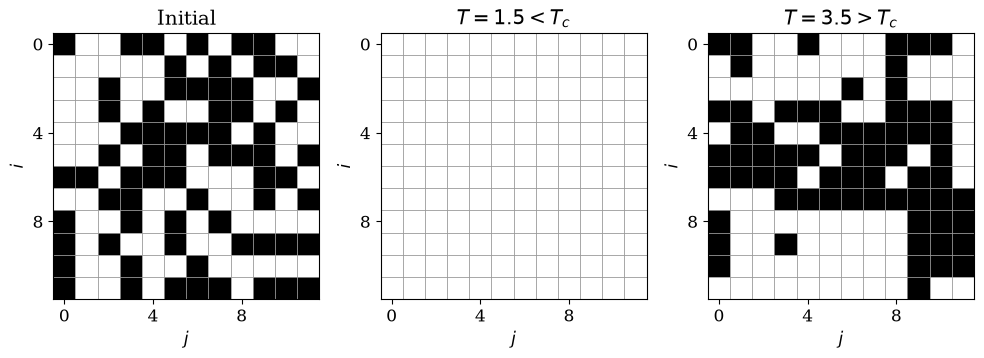

In [27]:
states_to_show = [initial, final_states[0], final_states[1]]
titles = ["Initial", r"$T=1.5<T_c$", r"$T=3.5>T_c$"]
plt.figure(figsize=(10, 3.5))
for k in range(3):
    plt.subplot(1, 3, k + 1)
    show_spins(states_to_show[k])
    plt.xticks(range(0, len(initial), 4))
    plt.yticks(range(0, len(initial), 4))
    plt.title(titles[k])
plt.tight_layout()
plt.show()

Below $T_c$, most spins align and $|m|$ is large. Either sign can be selected.
Above $T_c$, the spins remain mixed and $m$ fluctuates around zero.
The trace shows how each run evolves from the same initial magnetization.

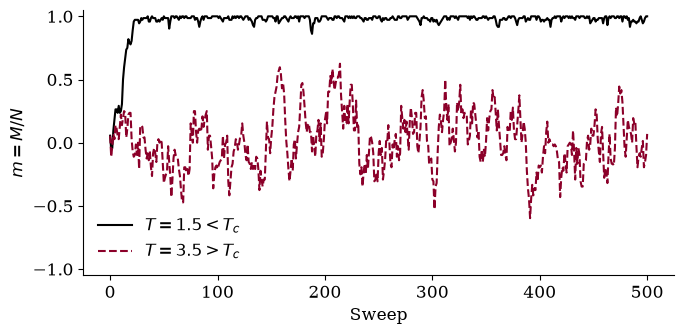

In [28]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(m_traces[0], color="black", label=r"$T=1.5<T_c$")
ax.plot(m_traces[1], color="#8B0029", linestyle="--", label=r"$T=3.5>T_c$")
ax.set_xlabel("Sweep")
ax.set_ylabel(r"$m=M/N$")
ax.set_ylim(-1.05, 1.05)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Compare:** which run develops a large magnetization? Which remains close to zero?
These finite-lattice examples illustrate ordering; they do not determine a sharp transition temperature.

### Check your understanding

1. Why do we count only right and down bonds in `total_energy`?
2. What would go wrong if we replaced `trial = spins.copy()` with `trial = spins`?
3. Why can the energy increase during a Monte Carlo run?
4. What do we record after a rejected proposal?

**Next:** relaxation and equilibrium averages. The total-energy difference remains our reference when we later derive a faster local update.